<a href="https://colab.research.google.com/github/SurajKhomane108/brain-tumor-classification-localization/blob/main/brain_tumor_classification_localization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automated Brain Tumour Classification and Bounding-Box Localization from MRI Images
### using Machine Learning, Deep Learning and a Genetic Algorithm

Dataset: Figshare brain tumour dataset (Cheng et al.) - 3064 T1-weighted contrast-enhanced MRI
slices from 233 patients. Three tumour types: meningioma (708), glioma (1426), pituitary (930).

**We are doing two things with this data:**

| | Task | Predict | From | Type |
|---|---|---|---|---|
| A | Classification | which of 3 tumour types | the image | supervised, nominal |
| B | Localization | the tumour's bounding box (4 numbers) | the image | supervised, continuous |

Task B is our regression problem.

---
# Part 0 - What we can and cannot do with this data

Each `.mat` file has one struct `cjdata` with five fields:

| Field | What it is |
|---|---|
| `image` | 512x512 MRI slice - **the only input we are allowed** |
| `label` | 1/2/3 tumour type - annotation |
| `tumorBorder` | hand-drawn outline coordinates - annotation |
| `tumorMask` | binary tumour region - annotation |
| `PID` | patient ID (233 unique, ~13 slices each) |

The image is the input. The label, border and mask are all things a radiologist drew by hand, so
they are targets, not inputs. On a new patient they do not exist - that is why we are building a
model at all.

### Picking the regression target

We went through the options before writing any code:

| Idea | Verdict |
|---|---|
| tumour type | valid, but nominal - that is classification, not regression |
| **bounding box from the mask** | **valid, continuous, 4 targets - this is what we use** |
| tumour area from perimeter | **no** - both come from the same mask, so it is a unit conversion, not a prediction |
| tumour area from image texture | fine but redundant, the box already gives us `w x h` |
| patient age / tumour grade | not in the dataset |

The area-from-perimeter idea was our first attempt and it was wrong. For a roughly round region
$A = P^2/4\pi$, so it gets a high R-squared while predicting nothing. It also fails the deployment
test: if we already have the mask to measure the perimeter, we already have the area.

So the rule for the whole notebook: **no feature computed from `tumorMask` or `tumorBorder` is ever
used as an input.** Features come from pixels only.

### Regression on images

The target is the box - the smallest rectangle round the tumour, written as centre and size and
divided by the image dimensions so everything lands in [0,1]:

$$(c_x,\ c_y,\ w,\ h)$$

For the input we turn each image into a fixed-length vector of numbers (Part 2), which makes every
row an ordinary tabular sample. Part 10 does it the other way and lets a CNN learn the features.
Comparing the two is the point of the project.

---
# Part 1 - Loading the data

Downloads the dataset on Colab and sets everything up. `CONFIG` holds all the settings in one
place.

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules
EXTRACT_DIR = "/content/data/raw_mat"

if IN_COLAB:
    !pip install h5py scikit-image -q
    if not os.path.isdir(EXTRACT_DIR) or len(os.listdir(EXTRACT_DIR)) == 0:
        !wget -q --show-progress -O /content/figshare.zip "https://ndownloader.figshare.com/articles/1512427/versions/5"
        !mkdir -p /content/figshare_raw && unzip -q /content/figshare.zip -d /content/figshare_raw
        !mkdir -p {EXTRACT_DIR}
        import glob as _g
        for part in sorted(_g.glob("/content/figshare_raw/*.zip")):
            !unzip -q -o {part} -d {EXTRACT_DIR}

CONFIG = {
    "IMG_SIZE": 128,      # images resized to this
    "GRID": 8,            # spatial features use an 8x8 grid
    "SEED": 42,
    "TRAIN_FRAC": 0.8,
    "BRIGHT_PCTL": 95,    # a pixel is "bright" if above this percentile
    "CNN_EPOCHS": 30,
    "GA_POP": 24,
    "GA_GENS": 20,
}
SEED = CONFIG["SEED"]
os.makedirs("cache", exist_ok=True)
os.makedirs("paper", exist_ok=True)   # results tables for the write-up land here
print(CONFIG)

/content/figshare.z 100%[===================>] 838.76M  20.1MB/s    in 44s     
{'IMG_SIZE': 128, 'GRID': 8, 'SEED': 42, 'TRAIN_FRAC': 0.8, 'BRIGHT_PCTL': 95, 'CNN_EPOCHS': 30, 'GA_POP': 24, 'GA_GENS': 20}


Imports. `h5py` because these `.mat` files are HDF5 v7.3, which `scipy.io.loadmat` cannot read.

In [2]:
import glob, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py, cv2
import scipy.stats as stats
from scipy.stats import skew, kurtosis
from skimage.feature import graycomatrix, graycoprops

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
LABEL_MAP = {1: "meningioma", 2: "glioma", 3: "pituitary"}

os.makedirs("results", exist_ok=True)

def save_results(rows, name):
    "Each assignment drops its scores here; the mini project collects them all."
    pd.DataFrame(rows).to_csv("results/%s.csv" % name, index=False)
    print("saved results/%s.csv" % name)

def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)
    try:
        import torch
        torch.manual_seed(s)
        torch.cuda.manual_seed_all(s)
    except ImportError:
        pass

def find_data_dir():
    for c in ["/content/data/raw_mat", "data/raw_mat", "."]:
        if os.path.isdir(c) and glob.glob(os.path.join(c, "*.mat")):
            return c
    for root, _, files in os.walk("/kaggle/input"):
        if any(f.endswith(".mat") for f in files):
            return root

set_seed()
DATA_DIR = find_data_dir()
print("Data:", DATA_DIR, "|", len(glob.glob(DATA_DIR + "/*.mat")), "files")

Data: /content/data/raw_mat | 3064 files


Now we build an index of all 3064 files, and while we are at it we work out the bounding box for
each one from its mask. The box is just the min and max of the non-zero mask pixels, converted to
centre-and-size and divided by the image dimensions.

$$c_x=\frac{x_{min}+x_{max}}{2W},\quad c_y=\frac{y_{min}+y_{max}}{2H},\quad
  w=\frac{x_{max}-x_{min}}{W},\quad h=\frac{y_{max}-y_{min}}{H}$$

Dividing by $W$ and $H$ makes the four numbers dimensionless, so they mean the same thing on any
image size and we can resize the image later without touching the targets.

In [3]:
def read_pid(f):
    return "".join(chr(int(c[0])) for c in f["cjdata"]["PID"][()]).strip()

def mask_to_box(mask):
    ys, xs = np.nonzero(mask)
    H, W = mask.shape
    x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
    return ((x0 + x1) / 2 / W, (y0 + y1) / 2 / H, (x1 - x0) / W, (y1 - y0) / H)

if os.path.exists("cache/index.csv"):
    df = pd.read_csv("cache/index.csv")
else:
    rows = []
    for p in sorted(glob.glob(DATA_DIR + "/*.mat")):
        with h5py.File(p, "r") as f:
            label = int(np.array(f["cjdata"]["label"]).flatten()[0])
            pid = read_pid(f)
            mask = np.array(f["cjdata"]["tumorMask"]).astype(np.uint8)
        cx, cy, bw, bh = mask_to_box(mask)
        rows.append({"path": p, "label": label, "label_name": LABEL_MAP[label], "pid": pid,
                     "cx": cx, "cy": cy, "bw": bw, "bh": bh,
                     "area_frac": mask.sum() / mask.size})
    df = pd.DataFrame(rows)
    df.to_csv("cache/index.csv", index=False)

print(len(df), "slices from", df["pid"].nunique(), "patients")
print(df["label_name"].value_counts().to_string())
print()
print(df[["cx", "cy", "bw", "bh", "area_frac"]].describe().loc[["mean", "std", "min", "max"]].round(3))

3064 slices from 233 patients
label_name
glioma        1426
pituitary      930
meningioma     708

         cx     cy     bw     bh  area_frac
mean  0.454  0.500  0.144  0.145      0.017
std   0.114  0.100  0.070  0.068      0.014
min   0.122  0.248  0.027  0.029      0.001
max   0.771  0.793  0.566  0.652      0.097


3064 slices, 233 patients, and the class counts match the dataset description.

The bit that matters for later: `cx` and `cy` average around 0.45-0.50 with a standard deviation of
roughly 0.09-0.12. That standard deviation is the number every regression model has to beat -
predicting the mean box every time gives exactly that RMSE and an R-squared of 0.

Tumours take up about 1-2% of a slice on average, so they are small objects. That makes
localization harder than it sounds: being off by a few pixels wrecks the overlap score.

Before trusting any of that, let's look at the images and check the boxes actually land on the
tumours.

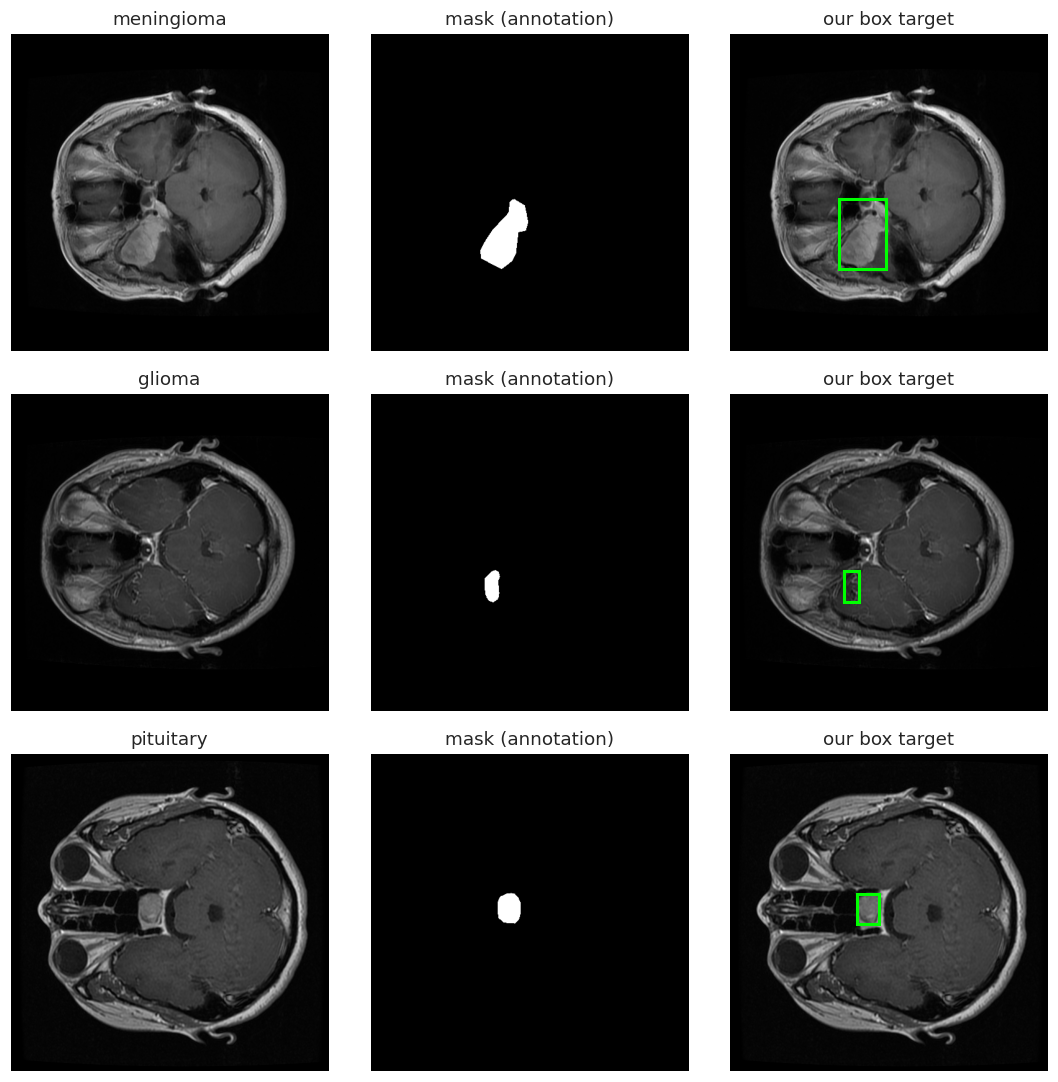

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for r, cls in enumerate(["meningioma", "glioma", "pituitary"]):
    row = df[df["label_name"] == cls].iloc[0]
    with h5py.File(row["path"], "r") as f:
        img = np.array(f["cjdata"]["image"]).astype(np.float32)
        mask = np.array(f["cjdata"]["tumorMask"]).astype(np.uint8)
    H, W = mask.shape
    axes[r, 0].imshow(img, cmap="gray"); axes[r, 0].set_title(cls)
    axes[r, 1].imshow(mask, cmap="gray"); axes[r, 1].set_title("mask (annotation)")
    axes[r, 2].imshow(img, cmap="gray")
    axes[r, 2].add_patch(plt.Rectangle(((row.cx - row.bw / 2) * W, (row.cy - row.bh / 2) * H),
                                       row.bw * W, row.bh * H, fill=False, ec="lime", lw=2))
    axes[r, 2].set_title("our box target")
    for c in range(3):
        axes[r, c].axis("off")
plt.tight_layout(); plt.show()

The green boxes sit tightly around the white mask regions, so `mask_to_box` is doing the right
thing.

Something else is visible here that turns out to matter a lot later. The three types sit in
characteristically different places - pituitary tumours are central and low, at the base of the
brain; meningiomas sit at the edge against the skull; gliomas are scattered through the tissue. So
position carries information about the class. We come back to this in Part 6.

Some EDA on the class balance and the box targets.

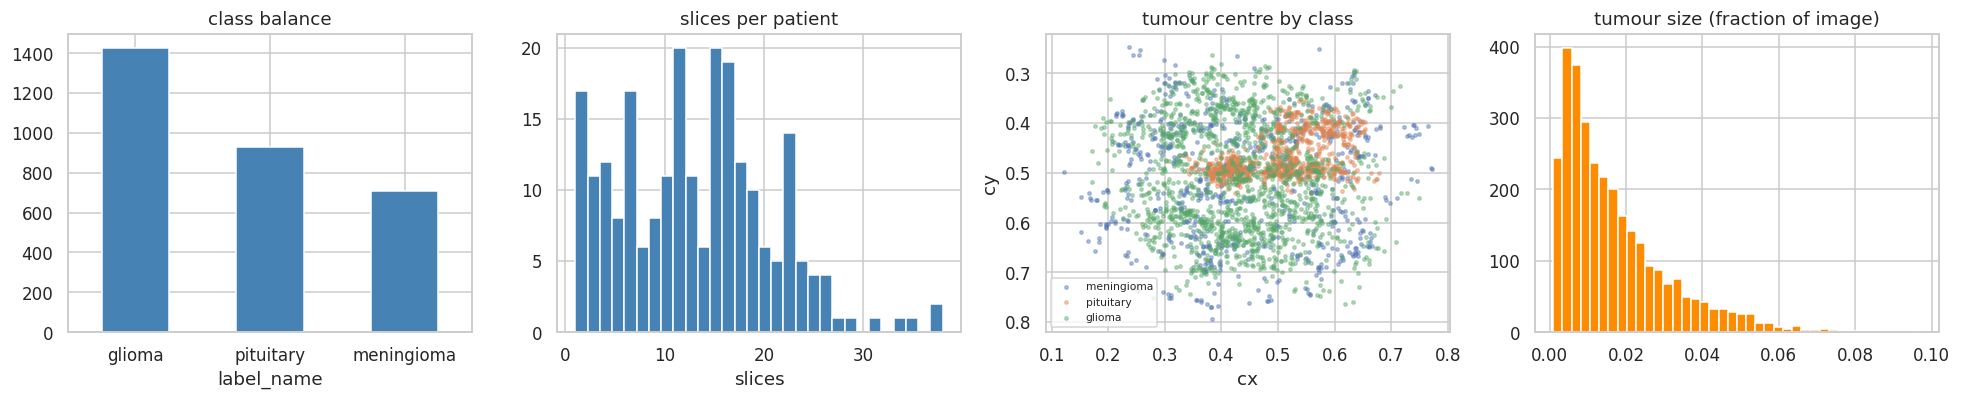

               cx     cy     bw     bh
label_name                            
glioma      0.430  0.514  0.172  0.172
meningioma  0.436  0.516  0.145  0.147
pituitary   0.503  0.467  0.098  0.101


In [5]:
fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
df["label_name"].value_counts().plot(kind="bar", ax=ax[0], color="steelblue", rot=0)
ax[0].set_title("class balance")

df.groupby("pid").size().hist(bins=30, ax=ax[1], color="steelblue")
ax[1].set_xlabel("slices"); ax[1].set_title("slices per patient")

for cls in df["label_name"].unique():
    s = df[df["label_name"] == cls]
    ax[2].scatter(s["cx"], s["cy"], s=5, alpha=0.4, label=cls)
ax[2].invert_yaxis(); ax[2].legend(fontsize=7); ax[2].set_title("tumour centre by class")
ax[2].set_xlabel("cx"); ax[2].set_ylabel("cy")

df["area_frac"].hist(bins=40, ax=ax[3], color="darkorange")
ax[3].set_title("tumour size (fraction of image)")
plt.tight_layout(); plt.show()

print(df.groupby("label_name")[["cx", "cy", "bw", "bh"]].mean().round(3).to_string())

Glioma is about half the data, so accuracy alone will be misleading later - a model that always
guessed glioma would be right 47% of the time. From Part 6 onwards we report macro-averaged F1,
which weights all three classes equally.

The slices-per-patient histogram is why we cannot use a normal random split. With ~13 slices per
patient, consecutive slices are nearly the same image. Split randomly and near-copies land in both
train and test, and every score comes out too high.

The centre scatter confirms what we saw in the images - pituitary tumours cluster in a tight low
central group, the other two spread more widely.

So we split by patient: 80% of the 233 patients go to train, the rest to test, and all of a
patient's slices go with them.

In [6]:
rng = np.random.RandomState(SEED)
pids = df["pid"].unique().copy()
rng.shuffle(pids)
train_pids = set(pids[:int(len(pids) * CONFIG["TRAIN_FRAC"])])
df["split"] = np.where(df["pid"].isin(train_pids), "train", "test")

print(df["split"].value_counts().to_string())
print("\npatients:", df.groupby("split")["pid"].nunique().to_dict())
print("\nclass mix per split:")
print(pd.crosstab(df["split"], df["label_name"], normalize="index").round(3).to_string())

split
train    2393
test      671

patients: {'test': 47, 'train': 186}

class mix per split:
label_name  glioma  meningioma  pituitary
split                                    
test         0.514       0.279      0.207
train        0.452       0.218      0.331


2393 training slices and 671 test slices - not exactly 80/20 because patients contribute unequal
numbers of slices, which is expected. The class mix stays close between the two splits, so the test
set is measuring the same problem the model trained on.

This split is fixed now and every model in the notebook uses it.

---
# Part 2 - Preprocessing and features

Normalise intensity to 0-255 (different scanners produce different ranges), a light 3x3 blur to
kill noise, and resize to 128x128 so every image gives the same number of features. The blur is
deliberately small - a wide one would smooth away the texture we are about to measure.

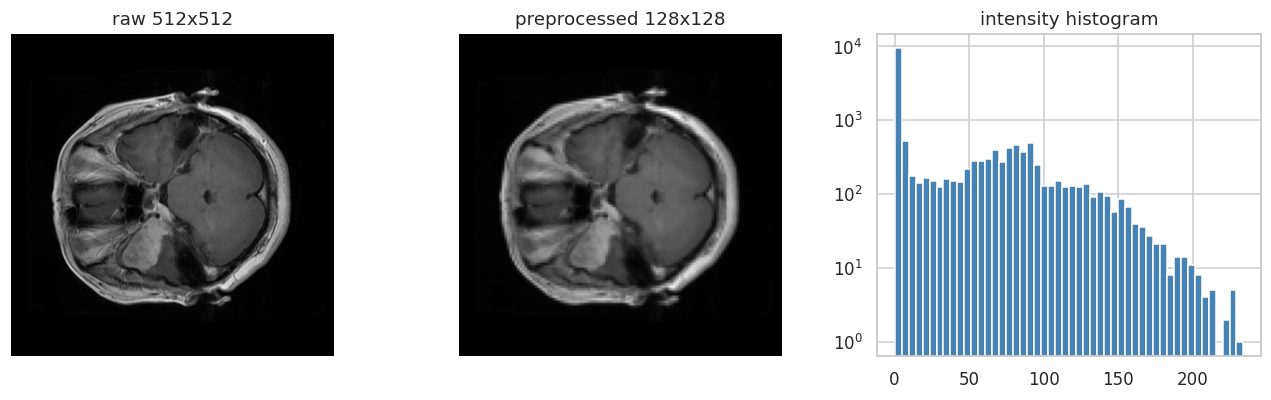

In [7]:
IMG_SIZE = CONFIG["IMG_SIZE"]

def preprocess(raw):
    img = cv2.normalize(raw, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

with h5py.File(df.iloc[0]["path"], "r") as f:
    raw = np.array(f["cjdata"]["image"]).astype(np.float32)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
ax[0].imshow(raw, cmap="gray"); ax[0].set_title("raw 512x512"); ax[0].axis("off")
ax[1].imshow(preprocess(raw), cmap="gray"); ax[1].set_title("preprocessed 128x128"); ax[1].axis("off")
ax[2].hist(preprocess(raw).ravel(), bins=50, color="steelblue"); ax[2].set_yscale("log")
ax[2].set_title("intensity histogram")
plt.tight_layout(); plt.show()

The preprocessed image looks the same as the raw one, which is what we want. The histogram has a
big spike at 0 (black background outside the head) and a bright tail on the right - that tail is
contrast-enhanced tumour tissue, and we build a feature to exploit it in a moment.

We build **two separate sets of features**, and keeping them apart is the most important design
decision in the notebook.

**Bank A - global appearance (16 features).** GLCM texture (contrast, correlation, energy,
homogeneity, dissimilarity, ASM, averaged over 2 distances and 4 angles), intensity statistics
(mean, variance, skew, kurtosis, 3 percentiles), and edge statistics (Sobel mean/std, Laplacian
variance).

Every one of these pools over the whole image. That means they describe *what the image looks like*
and carry no information about *where* anything is - move the tumour and they barely change. We
prove that in Part 4.4 rather than just claiming it.

In [8]:
GLCM_PROPS = ["contrast", "correlation", "energy", "homogeneity", "dissimilarity", "ASM"]

def extract_global(img):
    q = (img // 4).astype(np.uint8)          # quantise to 64 grey levels for speed
    glcm = graycomatrix(q, distances=[1, 3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=64, symmetric=True, normed=True)
    f = {"glcm_" + p: float(graycoprops(glcm, p).mean()) for p in GLCM_PROPS}

    x = img.astype(np.float32) / 255.0
    v = x.ravel()
    f["int_mean"] = float(v.mean())
    f["int_var"] = float(v.var())
    f["int_skew"] = float(skew(v))
    f["int_kurt"] = float(kurtosis(v))
    f["int_p10"], f["int_p50"], f["int_p90"] = [float(np.percentile(v, p)) for p in (10, 50, 90)]

    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)
    f["grad_mean"], f["grad_std"] = float(mag.mean()), float(mag.std())
    f["lap_var"] = float(cv2.Laplacian(img, cv2.CV_64F).var())
    return f

print(len(extract_global(preprocess(raw))), "global features")

16 global features


**Bank B - spatial grid (196 features).** Cut the image into an 8x8 grid of 16x16 cells and
describe each cell separately: mean intensity, standard deviation, and the fraction of pixels above
the image's 95th percentile. Plus the centroid and spread of all the bright pixels.

The bright-fraction feature is the one aimed at our problem. These are contrast-enhanced scans, so
tumour tissue lights up, and "which cells have unusually many bright pixels" is a crude tumour
detector. Crucially it is position-aware, because there is one value per cell.

8x8x3 + 4 = 196 features. Neighbouring cells will be correlated, and 196 features is a lot - both
of which become the point of Part 5.

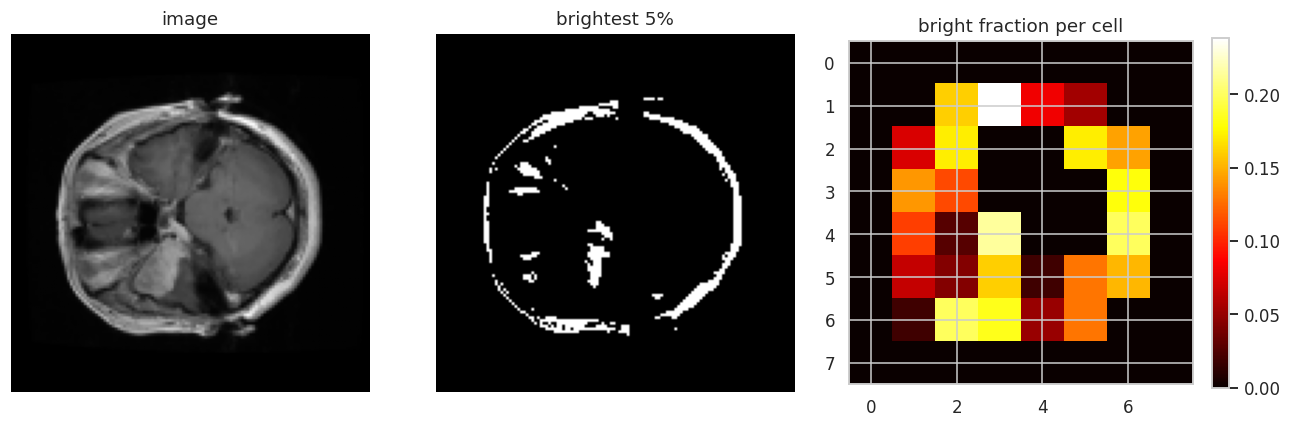

196 grid features


In [9]:
GRID = CONFIG["GRID"]

def extract_grid(img, grid=GRID, pctl=CONFIG["BRIGHT_PCTL"]):
    x = img.astype(np.float32) / 255.0
    bright = (x >= np.percentile(x, pctl)).astype(np.float32)
    cell = x.shape[0] // grid
    f = {}
    for r in range(grid):
        for c in range(grid):
            b = x[r*cell:(r+1)*cell, c*cell:(c+1)*cell]
            bb = bright[r*cell:(r+1)*cell, c*cell:(c+1)*cell]
            f["g%d%d_mean" % (r, c)] = float(b.mean())
            f["g%d%d_std" % (r, c)] = float(b.std())
            f["g%d%d_bright" % (r, c)] = float(bb.mean())
    ys, xs = np.nonzero(bright)
    H, W = x.shape
    f["bright_cx"], f["bright_cy"] = float(xs.mean() / W), float(ys.mean() / H)
    f["bright_sx"], f["bright_sy"] = float(xs.std() / W), float(ys.std() / H)
    return f

img0 = preprocess(raw)
g = extract_grid(img0)
gm = np.array([[g["g%d%d_bright" % (r, c)] for c in range(GRID)] for r in range(GRID)])

fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
ax[0].imshow(img0, cmap="gray"); ax[0].set_title("image"); ax[0].axis("off")
ax[1].imshow(img0 >= np.percentile(img0, 95), cmap="gray"); ax[1].set_title("brightest 5%"); ax[1].axis("off")
im = ax[2].imshow(gm, cmap="hot"); ax[2].set_title("bright fraction per cell")
plt.colorbar(im, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()
print(len(g), "grid features")

The bright mask picks up the tumour, but it also picks up skull, fat and other enhancing tissue -
so this feature finds bright things, and a tumour is only one kind of bright thing. That is its
honest limitation.

Run both extractors over all 3064 images. We also keep the preprocessed images in one array so the
CNN in Part 10 does not have to reopen 3064 HDF5 files. Cached, so this is slow once (about 80
seconds) and instant afterwards.

In [10]:
if os.path.exists("cache/features.csv"):
    feat_df = pd.read_csv("cache/features.csv")
    X_img = np.load("cache/images.npy")
else:
    rows, imgs = [], np.zeros((len(df), IMG_SIZE, IMG_SIZE), np.uint8)
    t0 = time.time()
    for i, r in enumerate(df.itertuples(index=False)):
        with h5py.File(r.path, "r") as f:
            img = preprocess(np.array(f["cjdata"]["image"]).astype(np.float32))
        imgs[i] = img
        d = extract_global(img)
        d.update(extract_grid(img))
        rows.append(d)
        if (i + 1) % 1000 == 0:
            print(" ", i + 1, "/", len(df), "%.0fs" % (time.time() - t0))
    feat_df, X_img = pd.DataFrame(rows), imgs
    feat_df.to_csv("cache/features.csv", index=False)
    np.save("cache/images.npy", X_img)

GLOBAL_COLS = [c for c in feat_df.columns if c.startswith(("glcm_", "int_", "grad_", "lap_"))]
GRID_COLS = [c for c in feat_df.columns if c not in GLOBAL_COLS]
ALL_COLS = GLOBAL_COLS + GRID_COLS

data = pd.concat([feat_df, df[["label", "label_name", "pid", "split",
                               "cx", "cy", "bw", "bh", "area_frac"]]], axis=1)

print("images:", X_img.shape)
print("features: %d global + %d grid = %d, on %d rows"
      % (len(GLOBAL_COLS), len(GRID_COLS), len(ALL_COLS), len(data)))
print("missing values:", data[ALL_COLS].isna().sum().sum())

  1000 / 3064 23s
  2000 / 3064 40s
  3000 / 3064 56s
images: (3064, 128, 128)
features: 16 global + 196 grid = 212, on 3064 rows
missing values: 0


212 features, 3064 rows, no missing values - unsurprising, since every feature is computed rather
than collected.

We are **not** capping outliers. Our first version of this project IQR-capped everything including
the regression target, which quietly squashed the top of the target range and made the problem
easier than reality. The box targets are already bounded in [0,1] by construction, and the extreme
feature values are real measurements from real scans. If outliers turn out to be a problem, RANSAC
in Part 4.7 will tell us.

The feature scales are wildly different (`glcm_contrast` in the hundreds, `int_var` around 0.02).
Plain linear regression does not care, but anything distance-based or penalised does, so we
standardise inside pipelines from Part 5 onward.

---
# Part 3 - Feature selection and PCA

Which of the 212 features are worth keeping? Unit I gives three approaches, and they answer
different questions. We run them for the classification task here; selection for the box task
happens in Part 5 where Lasso does it.

**Filter - ANOVA F-test.** Our target is nominal with 3 classes, so correlation with the label
would be meaningless (it would assume meningioma < glioma < pituitary is an ordering). The right
test is one-way ANOVA: does this feature's mean differ across the three classes?

$$F = \frac{\text{variance between class means}}{\text{variance within classes}}$$

Fast and model-free, but it scores each feature on its own, so it cannot tell that two features are
duplicates.

Top 12 features for classification:
           feature           F   bank
          g11_mean 1313.744925   grid
          g12_mean  911.964835   grid
           g11_std  907.676261   grid
          g20_mean  832.056394   grid
         bright_sy  815.356239   grid
           g20_std  806.871429   grid
glcm_dissimilarity  806.644733 global
          g30_mean  780.345090   grid
         grad_mean  778.422818 global
  glcm_homogeneity  776.640689 global
          int_mean  764.232326 global
           int_p50  682.689026 global

Bank split in the top 50: {'grid': 37, 'global': 13}


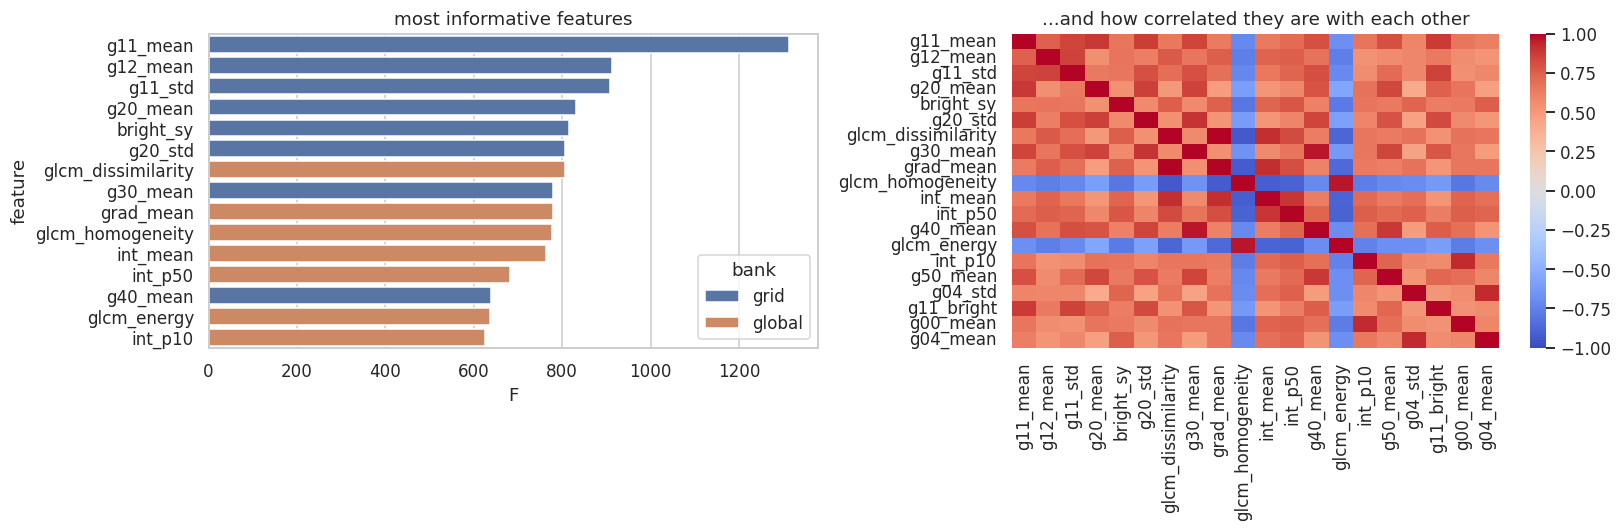


Pairs among the top 20 with |r| > 0.9: 11
Highest |r|: 0.998


In [11]:
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler

encoder = LabelEncoder()
data["y"] = encoder.fit_transform(data["label_name"])
CLASSES = list(encoder.classes_)
train_m, test_m = data["split"] == "train", data["split"] == "test"
tr = data[train_m]

F, p = f_classif(tr[ALL_COLS].values, tr["y"].values)
anova = pd.DataFrame({"feature": ALL_COLS, "F": F}).sort_values("F", ascending=False)
anova["bank"] = np.where(anova["feature"].isin(GLOBAL_COLS), "global", "grid")

print("Top 12 features for classification:")
print(anova.head(12).to_string(index=False))
print("\nBank split in the top 50:", anova.head(50)["bank"].value_counts().to_dict())

top20 = anova.head(20)["feature"].tolist()
corr = data[top20].corr()
off = corr.where(~np.eye(20, dtype=bool)).abs()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=anova.head(15), x="F", y="feature", hue="bank", dodge=False, ax=ax[0])
ax[0].set_title("most informative features")
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax[1])
ax[1].set_title("...and how correlated they are with each other")
plt.tight_layout(); plt.show()

print("\nPairs among the top 20 with |r| > 0.9:", int((off > 0.9).sum().sum() / 2))
print("Highest |r|: %.3f" % off.max().max())

The top of the ranking is dominated by grid features, not texture features. That is the position
effect again - the classes genuinely sit in different places, and ANOVA picks that up.

The heatmap shows the problem with filter methods. There are several pairs above 0.9 correlation
inside the top 20, and ANOVA has kept all of them because it scored each one separately. Adjacent
grid cells are the obvious culprit - a tumour spanning two cells drives both. `glcm_energy` and
`glcm_ASM` are worse: ASM is energy squared by definition, so that pair is a guaranteed duplicate
in our own feature bank.

**Wrapper - Recursive Feature Elimination.** RFE judges features by how the model actually performs
with them. It fits, drops the least useful feature, refits, and repeats - so when it removes one of
two duplicates, the other immediately looks more important. That is the thing ANOVA cannot do.

Its weakness is that it is greedy: each deletion is permanent, so it follows one path and never
reconsiders. That is the gap the genetic algorithm in Part 9 goes after.

We use a linear SVM as the base model for speed, with patient-grouped CV so the folds do not leak.

RFECV kept 107 of 212 features
of those, 12 global and 95 grid
overlap with ANOVA top-107: 69


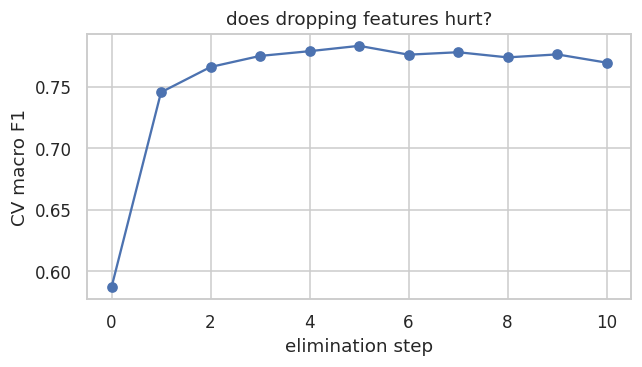

In [12]:
from sklearn.feature_selection import RFECV
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold, cross_val_score

X_tr_all, y_tr = tr[ALL_COLS].values, tr["y"].values
pid_tr = tr["pid"].values
gkf = GroupKFold(n_splits=4)

sc = StandardScaler().fit(X_tr_all)
rfecv = RFECV(LinearSVC(C=0.1, max_iter=5000, dual="auto"), step=0.1, min_features_to_select=5,
              cv=GroupKFold(3).split(X_tr_all, y_tr, pid_tr), scoring="f1_macro", n_jobs=-1)
rfecv.fit(sc.transform(X_tr_all), y_tr)
rfe_selected = [f for f, k in zip(ALL_COLS, rfecv.support_) if k]

print("RFECV kept %d of %d features" % (len(rfe_selected), len(ALL_COLS)))
print("of those, %d global and %d grid"
      % (sum(f in GLOBAL_COLS for f in rfe_selected), sum(f in GRID_COLS for f in rfe_selected)))
print("overlap with ANOVA top-%d: %d"
      % (len(rfe_selected), len(set(anova.head(len(rfe_selected))["feature"]) & set(rfe_selected))))

plt.figure(figsize=(6, 3.5))
plt.plot(rfecv.cv_results_["mean_test_score"], "o-")
plt.xlabel("elimination step"); plt.ylabel("CV macro F1")
plt.title("does dropping features hurt?")
plt.tight_layout(); plt.show()

RFECV settles on about 107 features, so roughly half of what we built was redundant, and the CV
curve barely drops while they are being removed. The overlap with the ANOVA top-107 is only
partial, which is the concrete demonstration that "score each feature alone" and "pick a good set
of features together" are different questions.

**PCA.** Different again - it does not select features, it rotates them into uncorrelated axes
ordered by variance. It is unsupervised, so it never looks at the labels. We use it to see how much
redundancy is in the 212 features and to get a 2-D picture.

Standardising first is essential: PCA maximises variance, and without scaling `glcm_contrast`
(hundreds) would swamp `int_var` (0.02) purely because of its units.

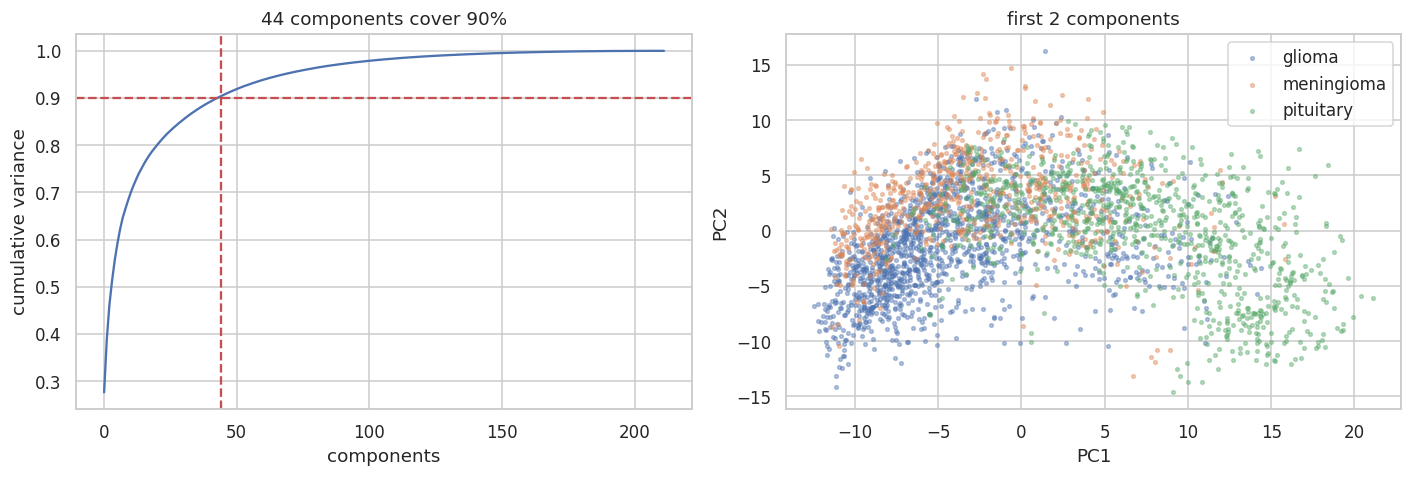

90% of the variance fits in 44 of 212 components


In [13]:
from sklearn.decomposition import PCA

sc_all = StandardScaler().fit(X_tr_all)
Z_all = sc_all.transform(data[ALL_COLS].values)
pca_full = PCA(random_state=SEED).fit(sc_all.transform(X_tr_all))
cum = np.cumsum(pca_full.explained_variance_ratio_)
k90 = int(np.searchsorted(cum, 0.90) + 1)
P = PCA(2, random_state=SEED).fit(sc_all.transform(X_tr_all)).transform(Z_all)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(cum); ax[0].axhline(0.9, color="r", ls="--"); ax[0].axvline(k90, color="r", ls="--")
ax[0].set_xlabel("components"); ax[0].set_ylabel("cumulative variance")
ax[0].set_title("%d components cover 90%%" % k90)
for i, c in enumerate(CLASSES):
    m = data["y"].values == i
    ax[1].scatter(P[m, 0], P[m, 1], s=6, alpha=0.4, label=c)
ax[1].legend(); ax[1].set_title("first 2 components"); ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
plt.tight_layout(); plt.show()

print("90%% of the variance fits in %d of %d components" % (k90, len(ALL_COLS)))

About 44 components hold 90% of the variance, so the 212 features really do contain a lot of
duplicated information - consistent with the correlation heatmap and with RFECV throwing half of
them away.

The 2-D scatter has heavy overlap between classes, but do not read too much into that. PCA picks
the directions of largest *variance*, not the directions that separate classes, so overlap here
does not mean the classes are inseparable. Part 6 settles that properly.

We do not pick a winner yet. Part 6 compares the full bank, the ANOVA subset, the RFECV subset and
PCA components with the same classifier and lets the numbers decide.

---
# Part 4 - Linear regression

**What we are predicting:** the tumour's bounding box - four numbers $(c_x, c_y, w, h)$ - from
features computed off the image pixels.

Unit II in full: the linear model, a two-variable example, multiple regression, the assumptions,
MAE/MSE/RMSE/R2/adjusted R2, polynomial regression and RANSAC. Regularisation is Part 5.

A linear model predicts a weighted sum of the inputs,

$$\hat{y} = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p$$

and OLS picks the weights that minimise squared error, $J(\beta)=\sum_i (y_i-\hat{y}_i)^2$, which
has the closed form $\hat\beta=(X^\top X)^{-1}X^\top y$. Squaring is why one badly wrong point
hurts far more than several slightly wrong ones - that comes back in 4.8.

## 4.1 First, what a working linear regression looks like

Our MRI data has no clean two-variable relationship in it, so before touching it we need a
reference point - what does linear regression look like on data it actually suits?

We use the Housing Prices dataset. Predicting house price from area, bedrooms,
bathrooms and so on is the textbook case: continuous target, continuous and binary predictors, a
genuine relationship.

The point is to have a **control**. Once we know what a healthy fit scores and what its residual
plot looks like, we can say precisely how the MRI case differs and why.

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Housing dataset: (545, 13) - predicting price
simple  (area only)    test R2 = 0.2729
multiple (13 features) test R2 = 0.6529   RMSE = 1324507


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


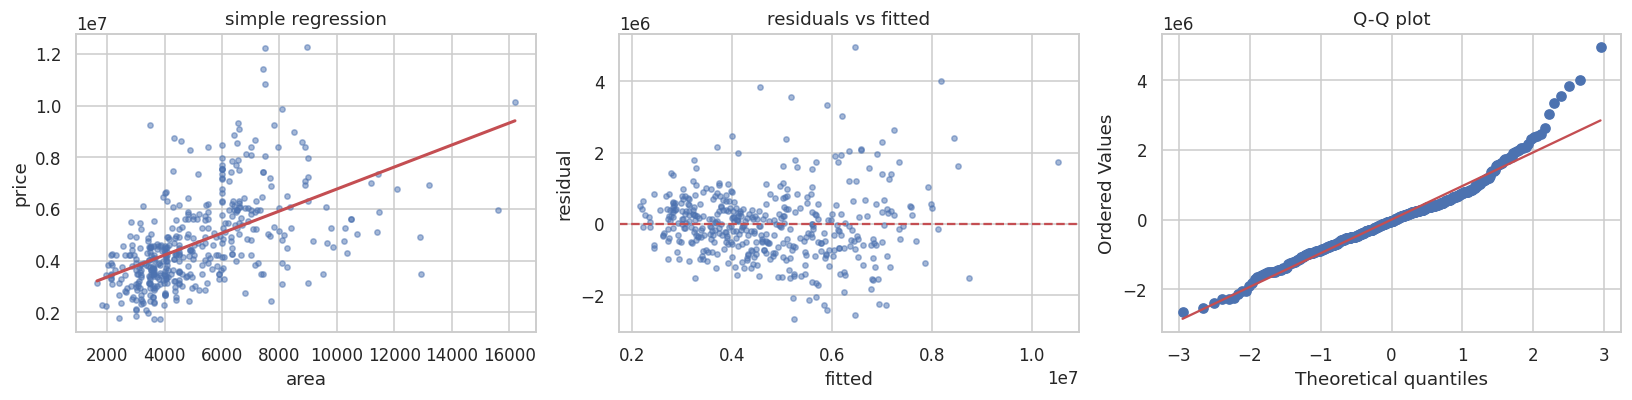

In [14]:
!pip install kagglehub -q
import kagglehub
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

house = pd.read_csv(os.path.join(
    kagglehub.dataset_download("yasserh/housing-prices-dataset"), "Housing.csv"))
for c in [c for c in house.columns if set(house[c].dropna().unique()) <= {"yes", "no"}]:
    house[c] = (house[c] == "yes").astype(int)
house = pd.get_dummies(house, columns=["furnishingstatus"], drop_first=True)

hX, hy = house.drop(columns="price"), house["price"]
hXtr, hXte, hytr, hyte = train_test_split(hX, hy, test_size=0.2, random_state=SEED)
print("Housing dataset:", hX.shape, "- predicting price")

simple = LinearRegression().fit(hXtr[["area"]], hytr)
multi = LinearRegression().fit(hXtr, hytr)
print("simple  (area only)    test R2 = %.4f" % r2_score(hyte, simple.predict(hXte[["area"]])))
print("multiple (13 features) test R2 = %.4f   RMSE = %.0f"
      % (r2_score(hyte, multi.predict(hXte)),
         mean_squared_error(hyte, multi.predict(hXte)) ** 0.5))

hfit = multi.predict(hXtr)
hres = hytr - hfit
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].scatter(hXtr["area"], hytr, s=12, alpha=0.5)
xs = np.linspace(hX["area"].min(), hX["area"].max(), 100).reshape(-1, 1)
ax[0].plot(xs, simple.predict(xs), "r-", lw=2)
ax[0].set_xlabel("area"); ax[0].set_ylabel("price"); ax[0].set_title("simple regression")
ax[1].scatter(hfit, hres, s=12, alpha=0.5); ax[1].axhline(0, color="r", ls="--")
ax[1].set_xlabel("fitted"); ax[1].set_ylabel("residual"); ax[1].set_title("residuals vs fitted")
stats.probplot(hres, dist="norm", plot=ax[2]); ax[2].set_title("Q-Q plot")
plt.tight_layout(); plt.show()

One feature (`area`) gets test R-squared **0.273**; all thirteen get **0.653**. On data that suits
it, multiple linear regression more than doubles what a single predictor manages, and you can see
the upward trend in the scatter with your own eyes.

The residual plot is not perfect - it fans out to the right (heteroscedasticity) and the Q-Q plot
lifts at the top because expensive houses get under-predicted. Real data rarely satisfies every
assumption. But it is a recognisable cloud around zero, and the model explains most of the variance.

**That 0.653 is the bar.** It is what "these features genuinely predict this target" looks like.
Our MRI numbers are about to look very different, and working out why is the rest of Part 4.

## 4.2 Our task: predicting the bounding box

Four targets, and the inputs are image features only - no mask-derived feature is ever an input.

Alongside the usual metrics we use **Intersection over Union**, the standard box metric:

$$IoU = \frac{\text{area}(P \cap T)}{\text{area}(P \cup T)}$$

1.0 is perfect overlap, 0.0 is none. It captures whether the centre and size are right *together*,
which the per-coordinate scores cannot. We also report the fraction of test images with IoU above
0.5, the usual "counts as a detection" threshold.

Two baselines, because an R-squared with nothing to compare it to is meaningless:

1. **Mean box** - always predict the average training box. Scores R2 about 0 by construction.
2. **Class-prior oracle** - predict the average training box *of the true class*. It is allowed to
   cheat by seeing the real label, so it is not a model; it is a ceiling on how well you can do
   using class identity alone. Since the three types grow in different places (Part 1), any model
   that merely recognises the type gets some localization for free. Beating this line is the real
   test.

In [15]:
BOX = ["cx", "cy", "bw", "bh"]
Ytr = data.loc[train_m, BOX].values
Yte = data.loc[test_m, BOX].values

def iou(a, b):
    def corners(z):
        return np.stack([z[:,0]-z[:,2]/2, z[:,1]-z[:,3]/2, z[:,0]+z[:,2]/2, z[:,1]+z[:,3]/2], 1)
    A, B = corners(a), corners(np.abs(b))
    x0 = np.maximum(A[:,0], B[:,0]); y0 = np.maximum(A[:,1], B[:,1])
    x1 = np.minimum(A[:,2], B[:,2]); y1 = np.minimum(A[:,3], B[:,3])
    inter = np.clip(x1-x0, 0, None) * np.clip(y1-y0, 0, None)
    union = (A[:,2]-A[:,0])*(A[:,3]-A[:,1]) + (B[:,2]-B[:,0])*(B[:,3]-B[:,1]) - inter
    return inter / union

def box_report(name, y_pred, y_true=None):
    y_true = Yte if y_true is None else y_true
    y_pred = y_pred.copy()
    y_pred[:, :2] = np.clip(y_pred[:, :2], 0, 1)
    y_pred[:, 2:] = np.clip(y_pred[:, 2:], 1e-3, 1)
    s = iou(y_true, y_pred)
    r = {"model": name}
    for j, c in enumerate(BOX):
        r["R2_" + c] = r2_score(y_true[:, j], y_pred[:, j])
    r["R2_mean"] = np.mean([r["R2_" + c] for c in BOX])
    r["mIoU"] = s.mean()
    r["IoU>0.5"] = (s > 0.5).mean()
    return r

mean_box = Ytr.mean(0)
class_box = data.loc[train_m].groupby("y")[BOX].mean()

results = [box_report("baseline: mean box", np.tile(mean_box, (len(Yte), 1))),
           box_report("oracle: class-prior box", class_box.loc[data.loc[test_m, "y"]].values)]

print("mean training box (cx, cy, w, h):", mean_box.round(3))
print("\nmean box per class:")
print(class_box.round(3).to_string())
print()
print(pd.DataFrame(results).round(4).to_string(index=False))

mean training box (cx, cy, w, h): [0.454 0.499 0.141 0.143]

mean box per class:
      cx     cy     bw     bh
y                            
0  0.423  0.513  0.170  0.172
1  0.443  0.521  0.144  0.146
2  0.503  0.467  0.099  0.101

                  model   R2_cx   R2_cy   R2_bw   R2_bh  R2_mean   mIoU  IoU>0.5
     baseline: mean box -0.0000 -0.0004 -0.0278 -0.0184  -0.0117 0.1188   0.0209
oracle: class-prior box  0.0115  0.0209  0.1934  0.2002   0.1065 0.1275   0.0387


The mean box scores R2 of essentially zero, as it must, and gets mIoU 0.119 - a constant prediction
still overlaps a bit because tumours are often near the middle. That is exactly why we do not judge
by IoU alone.

The oracle gets mIoU 0.128 and R2 0.107, and look where that comes from: almost all of it is in
`bw`/`bh` (about 0.19 each) and almost none in `cx`/`cy` (0.01-0.02). Knowing the tumour type tells
you a fair amount about how *big* it is and very little about *where* it is. Pituitary tumours are
noticeably smaller (w about 0.10) than meningiomas (0.17).

0.128 mIoU is the line to beat.

## 4.3 Attempt 1: the global appearance features

The obvious first go - 16 texture and intensity features, multiple linear regression, all four
targets.

In [16]:
Xg_tr, Xg_te = data.loc[train_m, GLOBAL_COLS].values, data.loc[test_m, GLOBAL_COLS].values

lin_global = LinearRegression().fit(Xg_tr, Ytr)
results.append(box_report("linear / global (16)", lin_global.predict(Xg_te)))
print(pd.DataFrame(results).round(4).to_string(index=False))

                  model   R2_cx   R2_cy   R2_bw   R2_bh  R2_mean   mIoU  IoU>0.5
     baseline: mean box -0.0000 -0.0004 -0.0278 -0.0184  -0.0117 0.1188   0.0209
oracle: class-prior box  0.0115  0.0209  0.1934  0.2002   0.1065 0.1275   0.0387
   linear / global (16)  0.0497  0.0116  0.0869  0.0991   0.0618 0.1360   0.0268


R-squared is 0.05 on `cx` and 0.01 on `cy`, against 0.09-0.10 on `bw` and `bh`. So the model has a
weak grip on the tumour's size and essentially none on its position, and the mIoU of 0.136 is
barely above the mean-box baseline.

The size/position split is not random, and it is worth understanding before trying a bigger model.
A larger tumour changes the overall brightness and texture of the slice, so size leaves a trace in
global statistics. Position does not - and the next section shows why that is not a fixable
weakness of linear regression.

## 4.4 Why global features cannot locate anything

Rather than argue it, we test it. Take some images and roll them sideways. `np.roll` shifts the
content and wraps it round the edge, so **not one pixel value is added or removed** - the set of
pixels is identical, only their arrangement changes.

That gives us something exact to check. Any feature that depends only on the pixel histogram -
mean, variance, skew, kurtosis, percentiles - must come out *identical*. Meanwhile the true $c_x$
has moved by the roll distance.

If two images can have the same features but different targets, no model can tell them apart. That
is a property of the features, not of the algorithm.

 roll_px  global_change  grid_change  true_cx_change
       0        0.00000      0.00000         0.00000
       4        0.00555      0.19383         0.03125
       8        0.00609      0.34652         0.06250
      16        0.00901      0.56627         0.12500

histogram-only features after a 16px roll:
  int_mean  0.0769895166  vs  0.0769895166
  int_var   0.0139948707  vs  0.0139948707
  int_skew  1.6715369225  vs  1.6715369225
  int_kurt  3.0185003281  vs  3.0184993744
  int_p50   0.0078431377  vs  0.0078431377


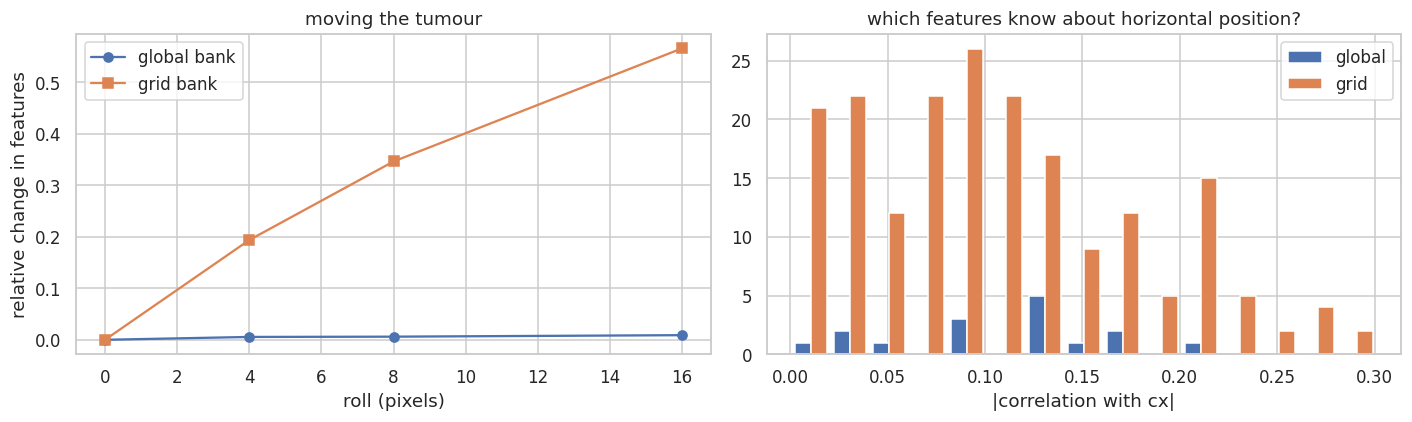


max |corr with cx|:  global 0.203   grid 0.301


In [17]:
set_seed()
sample = np.random.choice(len(data), 150, replace=False)
rows_shift = []
for s in [0, 4, 8, 16]:
    dg, dr = [], []
    for i in sample:
        a, b = X_img[i], np.roll(X_img[i], s, axis=1)
        g0 = np.array(list(extract_global(a).values())); g1 = np.array(list(extract_global(b).values()))
        r0 = np.array(list(extract_grid(a).values()));   r1 = np.array(list(extract_grid(b).values()))
        dg.append(np.linalg.norm(g1 - g0) / np.linalg.norm(g0))
        dr.append(np.linalg.norm(r1 - r0) / np.linalg.norm(r0))
    rows_shift.append({"roll_px": s, "global_change": np.mean(dg),
                       "grid_change": np.mean(dr), "true_cx_change": s / IMG_SIZE})
shift_df = pd.DataFrame(rows_shift)
print(shift_df.round(5).to_string(index=False))

a = extract_global(X_img[sample[0]]); b = extract_global(np.roll(X_img[sample[0]], 16, axis=1))
print("\nhistogram-only features after a 16px roll:")
for k in ["int_mean", "int_var", "int_skew", "int_kurt", "int_p50"]:
    print("  %-9s %.10f  vs  %.10f" % (k, a[k], b[k]))

cg = [abs(np.corrcoef(data[c], data["cx"])[0, 1]) for c in GLOBAL_COLS]
cr = [abs(np.corrcoef(data[c], data["cx"])[0, 1]) for c in GRID_COLS]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(shift_df["roll_px"], shift_df["global_change"], "o-", label="global bank")
ax[0].plot(shift_df["roll_px"], shift_df["grid_change"], "s-", label="grid bank")
ax[0].set_xlabel("roll (pixels)"); ax[0].set_ylabel("relative change in features")
ax[0].set_title("moving the tumour"); ax[0].legend()
ax[1].hist([cg, cr], bins=15, label=["global", "grid"])
ax[1].set_xlabel("|correlation with cx|"); ax[1].legend()
ax[1].set_title("which features know about horizontal position?")
plt.tight_layout(); plt.show()
print("\nmax |corr with cx|:  global %.3f   grid %.3f" % (max(cg), max(cr)))

The histogram features print identical to ten decimal places - the differences are 0 or around
1e-7, which is floating-point rounding from summing in a different order, not a real change.

Across the whole bank, a 16-pixel roll moves the global features by 0.9% and the grid features by
57% - about 63 times more. And the strongest correlation any global feature has with `cx` is 0.20,
against 0.30 for the grid features.

So the answer to "why was 4.3 so bad": we asked a model to predict position from features that
mathematically do not contain position. A random forest or a neural network on those same 16
numbers would have failed the same way. **The representation was the problem, not the algorithm** -
which tells us exactly what to change.

## 4.5 Attempt 2: the spatial grid features

Same algorithm, same targets, same split. Only the features change - 196 grid features that do
encode position.

We also fit a deliberately tiny model on just the 4 bright-pixel centroid features, to check
whether a simple centre-of-brightness gets most of the way there on its own.

In [18]:
Xr_tr, Xr_te = data.loc[train_m, GRID_COLS].values, data.loc[test_m, GRID_COLS].values
Xa_tr, Xa_te = data.loc[train_m, ALL_COLS].values, data.loc[test_m, ALL_COLS].values
CENT = ["bright_cx", "bright_cy", "bright_sx", "bright_sy"]
Xc_tr, Xc_te = data.loc[train_m, CENT].values, data.loc[test_m, CENT].values

for nm, A, B in [("linear / bright centroid (4)", Xc_tr, Xc_te),
                 ("linear / grid (196)", Xr_tr, Xr_te),
                 ("linear / global+grid (212)", Xa_tr, Xa_te)]:
    results.append(box_report(nm, LinearRegression().fit(A, Ytr).predict(B)))

print(pd.DataFrame(results).round(4).to_string(index=False))

                       model   R2_cx   R2_cy   R2_bw   R2_bh  R2_mean   mIoU  IoU>0.5
          baseline: mean box -0.0000 -0.0004 -0.0278 -0.0184  -0.0117 0.1188   0.0209
     oracle: class-prior box  0.0115  0.0209  0.1934  0.2002   0.1065 0.1275   0.0387
        linear / global (16)  0.0497  0.0116  0.0869  0.0991   0.0618 0.1360   0.0268
linear / bright centroid (4)  0.0123 -0.0113  0.0309  0.0397   0.0179 0.1346   0.0447
         linear / grid (196)  0.0431  0.2281  0.0969  0.0084   0.0941 0.1541   0.0626
  linear / global+grid (212)  0.0527  0.2010  0.0515 -0.0154   0.0725 0.1499   0.0507


The grid features move `cy` from 0.01 to 0.23 and `cx` from 0.05 to 0.04 - so vertical position
becomes genuinely predictable while horizontal position stays stubborn. Average centre R-squared
goes from 0.03 to 0.14 and mIoU from 0.136 to 0.154, which is now clearly past the oracle's 0.128.
Same regression, different features.

Why is `cy` so much easier than `cx`? Brains are roughly left-right symmetric, so brightness on the
left looks much like brightness on the right and horizontal position is genuinely ambiguous.
Vertically there is no such symmetry - skull, ventricles and the skull base all sit at
characteristic heights - so "how far down" is much easier to read off.

The 4-feature centroid model is the surprise: centre R-squared of 0.0005, no better than guessing.
Taking the centre of mass of all bright pixels does not find the tumour, because skull and other
enhancing tissue are bright too and they drag the centroid around. The per-cell detail in the full
grid is what lets the model learn *which* bright regions matter, and that is why 196 features beat
4.

Adding the global features on top (212) makes things slightly worse, not better. They contribute
nothing to localization, as 4.4 predicted, and they cost degrees of freedom. They earn their keep
in classification instead.

## 4.6 Checking the assumptions

Five assumptions behind linear regression. If they break, the model may still predict, but the
coefficients and any inference from them stop being trustworthy. We check on the grid model, using
`cx` as the target so the plots are readable.

For multicollinearity we use the variance inflation factor, $VIF_j = 1/(1-R^2_j)$ where $R^2_j$
comes from regressing feature $j$ on all the others. Above 10 is usually considered serious.

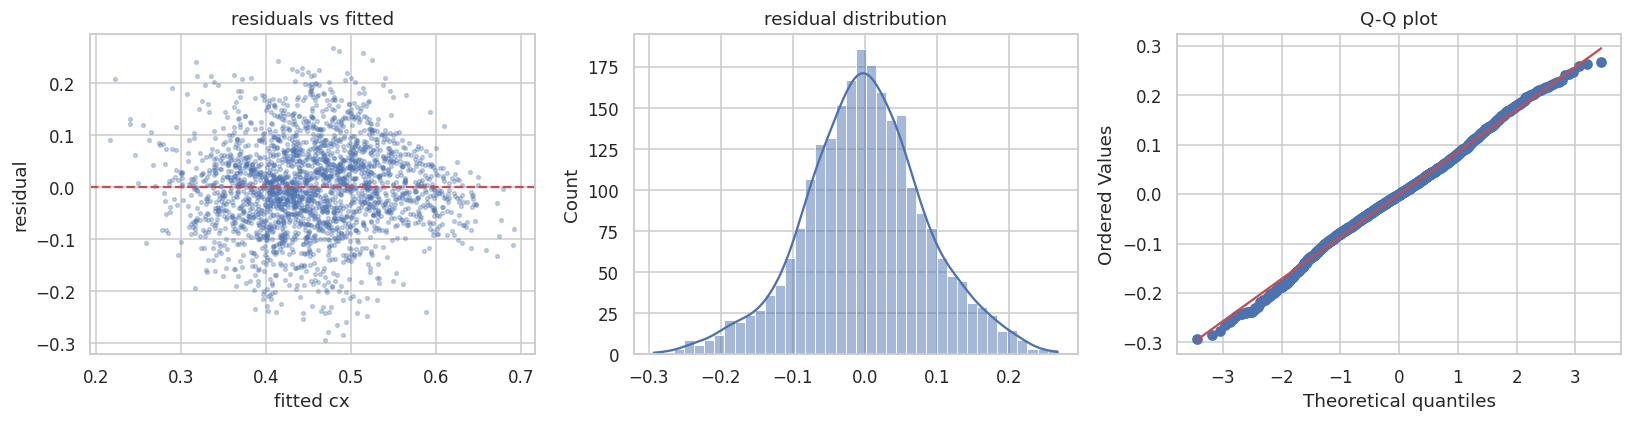

residual skew -0.048, kurtosis 0.328
corr(|residual|, fitted) = 0.058

worst VIFs (of 24 sampled grid features):
 feature       VIF
g02_mean 56.484857
g03_mean 55.921156
 g03_std 33.695204
g04_mean 27.753003
 g02_std 24.961606
g05_mean 21.288542
 g04_std 20.194887
g06_mean 19.782864

16 of 24 have VIF > 10


In [19]:
m_cx = LinearRegression().fit(Xr_tr, Ytr[:, 0])
fit = m_cx.predict(Xr_tr)
res = Ytr[:, 0] - fit

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(fit, res, s=6, alpha=0.3); ax[0].axhline(0, color="r", ls="--")
ax[0].set_xlabel("fitted cx"); ax[0].set_ylabel("residual"); ax[0].set_title("residuals vs fitted")
sns.histplot(res, bins=40, kde=True, ax=ax[1]); ax[1].set_title("residual distribution")
stats.probplot(res, dist="norm", plot=ax[2]); ax[2].set_title("Q-Q plot")
plt.tight_layout(); plt.show()

sub = GRID_COLS[:24]
Xs = data.loc[train_m, sub].values
vif = []
for j in range(Xs.shape[1]):
    other = np.delete(Xs, j, axis=1)
    vif.append(1 / (1 - LinearRegression().fit(other, Xs[:, j]).score(other, Xs[:, j])))
vif_df = pd.DataFrame({"feature": sub, "VIF": vif}).sort_values("VIF", ascending=False)

print("residual skew %.3f, kurtosis %.3f" % (stats.skew(res), stats.kurtosis(res)))
print("corr(|residual|, fitted) = %.3f" % abs(np.corrcoef(fit, np.abs(res))[0, 1]))
print("\nworst VIFs (of 24 sampled grid features):")
print(vif_df.head(8).to_string(index=False))
print("\n%d of %d have VIF > 10" % ((vif_df["VIF"] > 10).sum(), len(sub)))

Results, one assumption at a time.

**Linearity** - the residual plot is a formless band with no obvious curve, so unlike the synthetic
quadratic example in 4.1 we do not have an obviously mis-specified functional form.

**Homoscedasticity** - fine. The correlation between absolute residual and fitted value is 0.06,
essentially zero, so the spread is constant across the range.

**Normality** - fine. Skew is -0.05 and kurtosis 0.33, and the Q-Q plot is close to the diagonal.

**Multicollinearity** - badly violated. 16 of the 24 sampled grid features have VIF above 10, with
the worst around 56. This is unavoidable given how we built the features: adjacent cells overlap
the same anatomy, so `g02_mean` and `g03_mean` are nearly the same measurement. The consequence is
that individual coefficients are unstable - the model can put a large positive weight on one cell
and a large negative one on its neighbour and predict identically. It damages interpretation more
than prediction, and Ridge is the standard fix, which is Part 5.

**Independence** - violated by how the data was collected, and no model choice fixes it. 3064
slices come from 233 patients, so rows from one patient are near-duplicates and their errors are
correlated. Our patient-wise split stops this inflating the test score, but the rows are still not
independent. The proper treatment would be a mixed-effects model with a per-patient random effect,
which is outside Unit II.

## 4.7 Polynomial regression

Is the relationship curved rather than straight? We test on one well-posed sub-problem - predicting
box width from the 16 global features, since 4.3 showed size is the part global features have some
grip on. Expanding all 196 grid features to degree 2 would give over 19,000 terms on 2,393 rows,
which is guaranteed overfitting and teaches nothing.

Degree 2 on 16 features is 152 terms; degree 3 is 968. We use Ridge above degree 1 so the fit does
not blow up.

In [20]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

y_bw_tr, y_bw_te = Ytr[:, 2], Yte[:, 2]
poly = []
for d in [1, 2, 3]:
    est = LinearRegression() if d == 1 else Ridge(alpha=1.0)
    pipe = make_pipeline(PolynomialFeatures(d, include_bias=False), StandardScaler(), est)
    pipe.fit(Xg_tr, y_bw_tr)
    poly.append({"degree": d, "terms": pipe[0].n_output_features_,
                 "train_R2": r2_score(y_bw_tr, pipe.predict(Xg_tr)),
                 "test_R2": r2_score(y_bw_te, pipe.predict(Xg_te))})
poly_df = pd.DataFrame(poly)
poly_df["gap"] = poly_df["train_R2"] - poly_df["test_R2"]
print("target: box width, features: 16 global")
print(poly_df.round(4).to_string(index=False))

target: box width, features: 16 global
 degree  terms  train_R2  test_R2    gap
      1     16    0.1638   0.0869 0.0769
      2    152    0.2694   0.1009 0.1685
      3    968    0.3528   0.0949 0.2579


Degree 2 nudges test R-squared from 0.087 to 0.101 and degree 3 drops back to 0.095. Meanwhile the
train-test gap grows steadily: 0.08, 0.17, 0.26.

That is the bias-variance tradeoff in a single table. Training R-squared keeps climbing because
more terms can always fit the training data better; test R-squared does not follow, so the extra
terms are fitting noise. The gain from curvature is too small to be worth 152 terms, so the
straight-line form was not what was holding us back here.

## 4.8 RANSAC

OLS squares its errors, so a few extreme points can drag the whole fit. RANSAC instead fits on
random subsets, keeps whichever fit wins the most **inliers**, and refits on those - ignoring the
rest. It treats contamination, not variance.

Worth trying because we deliberately did not cap outliers in Part 2. This is where we find out if
that was the right call. Single target, since RANSAC does not do multi-output.

OLS    test R2 = 0.0869
RANSAC test R2 = 0.0500

inliers kept: 1307 / 2393 (54.6%)
mean bw  inliers 0.1320   discarded 0.1515


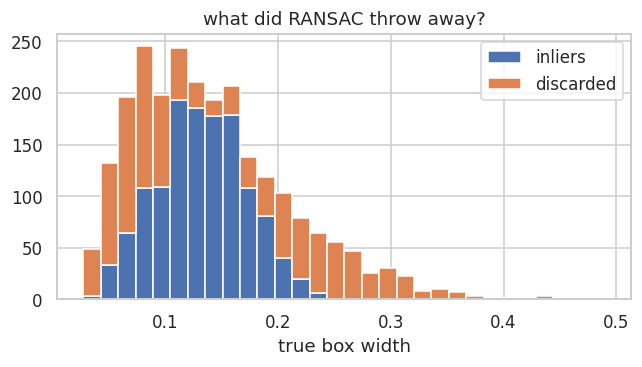

saved results/a2_localization.csv


In [21]:
from sklearn.linear_model import RANSACRegressor

sc_g = StandardScaler().fit(Xg_tr)
A, B = sc_g.transform(Xg_tr), sc_g.transform(Xg_te)
ols = LinearRegression().fit(A, y_bw_tr)
rs = RANSACRegressor(LinearRegression(), min_samples=0.5, max_trials=200,
                     random_state=SEED).fit(A, y_bw_tr)
inl = rs.inlier_mask_

print("OLS    test R2 = %.4f" % r2_score(y_bw_te, ols.predict(B)))
print("RANSAC test R2 = %.4f" % r2_score(y_bw_te, rs.predict(B)))
print("\ninliers kept: %d / %d (%.1f%%)" % (inl.sum(), len(inl), 100 * inl.mean()))
print("mean bw  inliers %.4f   discarded %.4f" % (y_bw_tr[inl].mean(), y_bw_tr[~inl].mean()))

plt.figure(figsize=(6, 3.5))
plt.hist([y_bw_tr[inl], y_bw_tr[~inl]], bins=30, stacked=True, label=["inliers", "discarded"])
plt.xlabel("true box width"); plt.legend(); plt.title("what did RANSAC throw away?")
plt.tight_layout(); plt.show()

save_results(results, "a2_localization")

RANSAC does worse - test R-squared 0.050 against OLS's 0.087 - and it threw away 45% of the
training data to get there.

The histogram shows why that was a bad trade. The discarded points are not a small corrupt
minority; they are spread across the range, with the discarded mean (0.152) only slightly above the
kept mean (0.132). There is no contaminated subset to remove here, just a weak relationship
everywhere, so all RANSAC achieved was training on less data.

Useful negative result: it tells us our error is spread evenly through the dataset rather than
caused by a few bad points, which retrospectively justifies not capping outliers in Part 2.

---
# Part 5 - Ridge, Lasso and ElasticNet

4.6 found badly violated multicollinearity and we are fitting 196 features. That is the textbook
case for regularisation, which adds a penalty on coefficient size and trades a little bias for less
variance.

**Ridge (L2)** shrinks coefficients smoothly toward zero but never to zero:
$J = \sum_i (y_i-\hat y_i)^2 + \alpha\sum_j \beta_j^2$. This is the direct fix for collinearity - it
stops two correlated cells taking huge opposite weights.

**Lasso (L1)** uses $\alpha\sum_j|\beta_j|$. The corner at zero means coefficients can be driven
*exactly* to zero, so it selects features.

**ElasticNet** mixes both. Lasso alone tends to pick one feature from a correlated group and drop
the rest arbitrarily; ElasticNet keeps or drops them together, which is usually what you want with
grid cells.

Standardising is mandatory - the penalty treats all coefficients equally, so an unscaled feature
with a small range would need a big coefficient and would eat the whole penalty budget. Alpha is
chosen by patient-grouped CV on the training set.

In [22]:
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV

alphas = [1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0]
reg_rows, tuned = [], {}

for nm, est in [("OLS", LinearRegression()), ("Ridge", Ridge()),
                ("Lasso", Lasso(max_iter=20000)),
                ("ElasticNet", ElasticNet(l1_ratio=0.5, max_iter=20000))]:
    pipe = make_pipeline(StandardScaler(), est)
    if nm == "OLS":
        best, tag = pipe.fit(Xr_tr, Ytr), ""
    else:
        key = [k for k in pipe.get_params() if k.endswith("__alpha")][0]
        gs = GridSearchCV(pipe, {key: alphas}, scoring="r2", cv=gkf, n_jobs=-1)
        gs.fit(Xr_tr, Ytr, groups=pid_tr)
        best, tag = gs.best_estimator_, " (a=%g)" % gs.best_params_[key]
    tuned[nm] = best
    r = box_report(nm + tag, best.predict(Xr_te))
    W = np.atleast_2d(best[-1].coef_)
    r["nonzero"] = int((np.abs(W) > 1e-8).sum())
    r["max|coef|"] = float(np.abs(W).max())
    reg_rows.append(r)

results.extend(reg_rows[1:])          # keep Ridge/Lasso/ElasticNet for the final table
print(pd.DataFrame(reg_rows).round(4).to_string(index=False))
save_results(reg_rows, "a3_localization")

              model  R2_cx  R2_cy  R2_bw  R2_bh  R2_mean   mIoU  IoU>0.5  nonzero  max|coef|
                OLS 0.0431 0.2281 0.0969 0.0084   0.0941 0.1541   0.0626      784     0.1010
       Ridge (a=10) 0.0932 0.2475 0.1368 0.0597   0.1343 0.1610   0.0581      784     0.0400
    Lasso (a=0.001) 0.2382 0.2924 0.2036 0.1810   0.2288 0.1792   0.0656      290     0.0297
ElasticNet (a=0.01) 0.2267 0.1714 0.1439 0.0862   0.1571 0.1735   0.0686       79     0.0185
saved results/a3_localization.csv


Regularisation helps on both counts here.

Accuracy: mean R-squared goes from 0.094 (OLS) to 0.229 (Lasso), and mIoU from 0.154 to 0.179.
Lasso improves every single coordinate, and it more than doubles `cx` from 0.043 to 0.238 - the
coordinate that had been resisting everything.

Stability: the largest coefficient shrinks from 0.101 to 0.030, and Lasso keeps only 290 of 784
coefficients non-zero. So most grid cells are irrelevant to most targets, which is a
feature-selection result we got for free.

That combination - better accuracy *and* smaller coefficients - is the signature of a model that
had been overfitting through collinear features. It also means the coefficients are now stable
enough to be worth reading, which is the next cell.

## 5.1 What the model learned, as a picture

The grid features have a spatial layout, so we can reshape the fitted coefficients back into an 8x8
image and look at them. Each cell shows how much brightness in that part of the image pushes the
prediction up or down.

This is the advantage of an interpretable model. The CNN in Part 10 will predict better but it will
not hand us anything this easy to explain, which matters in a medical setting.

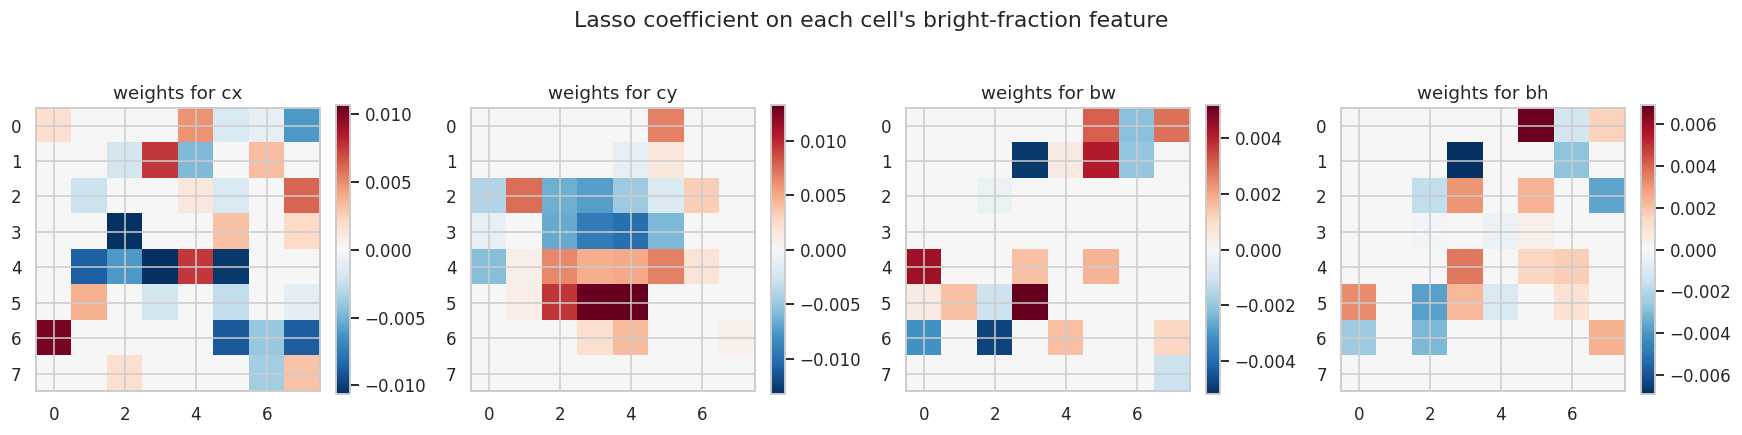

cx map, correlation between column index and mean weight: -0.273
cy map, correlation between row index and mean weight   : +0.264


In [23]:
W = np.atleast_2d(tuned["Lasso"][-1].coef_)
pos = {n: i for i, n in enumerate(GRID_COLS)}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
maps = []
for t, tgt in enumerate(BOX):
    m = np.array([[W[t, pos["g%d%d_bright" % (r, c)]] for c in range(GRID)] for r in range(GRID)])
    maps.append(m)
    lim = np.abs(m).max()
    im = axes[t].imshow(m, cmap="RdBu_r", vmin=-lim, vmax=lim)
    axes[t].set_title("weights for " + tgt)
    plt.colorbar(im, ax=axes[t], fraction=0.046)
plt.suptitle("Lasso coefficient on each cell's bright-fraction feature", y=1.03)
plt.tight_layout(); plt.show()

print("cx map, correlation between column index and mean weight: %+.3f"
      % np.corrcoef(np.arange(GRID), maps[0].mean(0))[0, 1])
print("cy map, correlation between row index and mean weight   : %+.3f"
      % np.corrcoef(np.arange(GRID), maps[1].mean(1))[0, 1])

The `cy` map shows the pattern we would expect: a top-to-bottom gradient with correlation +0.26, so
brightness lower down pushes the predicted centre lower down. That is the model doing arithmetic we
can follow.

The `cx` map does not show a clean left-to-right gradient - the correlation comes out around -0.27.
Given the left-right symmetry argument from 4.5, that is consistent rather than surprising:
horizontal position is the harder coordinate, so Lasso ends up keying on a few specific asymmetric
cells rather than a smooth gradient. It is worth being honest that this map is less interpretable
than the `cy` one.

The `bw` and `bh` maps look different again, and should - size does not depend on direction, so
there is no gradient to see, just cells that indicate a spread-out bright region.

Cells left white are ones Lasso zeroed out entirely. Many of them are around the edges, which is
background outside the skull, so the model has worked out on its own where the brain is.

---
# Part 6 - Classification

**What we are predicting:** which of the three tumour types, from the 212 image features.

This is the main task and there is nothing awkward about it - the label is a real annotation and
the features describe the image.

How we judge it. Accuracy alone is not enough because glioma is 47% of the data, so we report
**macro-averaged** precision/recall/F1, which weights the small meningioma class equally. Plus the
confusion matrix, to see *which* classes get mixed up, and one-vs-rest ROC-AUC.

Model choice is made on **patient-grouped cross-validation of the training set**, then we look at
the test set once. Choosing on the test set would be cheating.

In [24]:
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, roc_auc_score,
                             classification_report, confusion_matrix, roc_curve)

ytr, yte = data.loc[train_m, "y"].values, data.loc[test_m, "y"].values

def scores_of(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    d = model.decision_function(X)
    e = np.exp(d - d.max(1, keepdims=True))
    return e / e.sum(1, keepdims=True)

def clf_report(name, model, X, y=None):
    y = yte if y is None else y
    p = model.predict(X)
    pr, rc, f1, _ = precision_recall_fscore_support(y, p, average="macro", zero_division=0)
    return {"model": name, "accuracy": accuracy_score(y, p), "macro_P": pr, "macro_R": rc,
            "macro_F1": f1, "macro_AUC": roc_auc_score(y, scores_of(model, X), multi_class="ovr")}

MODELS = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "Perceptron":          make_pipeline(StandardScaler(), Perceptron(random_state=SEED)),
    "Naive Bayes":         make_pipeline(StandardScaler(), GaussianNB()),
    "Decision Tree":       DecisionTreeClassifier(max_depth=12, random_state=SEED),
    "KNN (k=7)":           make_pipeline(StandardScaler(), KNeighborsClassifier(7)),
    "SVM (RBF)":           make_pipeline(StandardScaler(), SVC(C=10, probability=True, random_state=SEED)),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=SEED),
    "MLP":                 make_pipeline(StandardScaler(), MLPClassifier((128,), max_iter=600, random_state=SEED)),
}

rows = []
for nm, m in MODELS.items():
    cv = cross_val_score(m, Xa_tr, ytr, cv=gkf.split(Xa_tr, ytr, pid_tr), scoring="f1_macro", n_jobs=-1)
    m.fit(Xa_tr, ytr)
    r = clf_report(nm, m, Xa_te)
    r["cv_F1"] = cv.mean()
    r["cv_std"] = cv.std()
    rows.append(r)
    print("  %-20s cv %.4f  test %.4f" % (nm, cv.mean(), r["macro_F1"]))

clf_df = pd.DataFrame(rows).sort_values("cv_F1", ascending=False).reset_index(drop=True)
print()
print(clf_df.round(4).to_string(index=False))
print("\nmajority-class accuracy = %.4f" % pd.Series(yte).value_counts(normalize=True).max())

  Logistic Regression  cv 0.7726  test 0.7420
  Perceptron           cv 0.7567  test 0.7330
  Naive Bayes          cv 0.6846  test 0.6825
  Decision Tree        cv 0.7543  test 0.7777
  KNN (k=7)            cv 0.7412  test 0.7486
  SVM (RBF)            cv 0.7984  test 0.7729
  Random Forest        cv 0.8384  test 0.8237
  Gradient Boosting    cv 0.8428  test 0.7887
  MLP                  cv 0.7784  test 0.7782

              model  accuracy  macro_P  macro_R  macro_F1  macro_AUC  cv_F1  cv_std
  Gradient Boosting    0.7988   0.7765   0.8100    0.7887     0.9374 0.8428  0.0189
      Random Forest    0.8346   0.8111   0.8470    0.8237     0.9418 0.8384  0.0300
          SVM (RBF)    0.7750   0.7607   0.7898    0.7729     0.9097 0.7984  0.0176
                MLP    0.7824   0.7680   0.7920    0.7782     0.9078 0.7784  0.0154
Logistic Regression    0.7452   0.7371   0.7488    0.7420     0.8867 0.7726  0.0204
         Perceptron    0.7258   0.7282   0.7542    0.7330     0.8685 0.7567  0.01

The tree ensembles win: Gradient Boosting tops the CV at 0.843 and Random Forest is just behind at
0.838. Everything comfortably beats the 0.514 majority-class baseline, so all of these models are
learning something real.

Note Gradient Boosting drops from 0.843 in CV to 0.789 on the test patients while Random Forest
holds up better (0.838 to 0.824). A gap like that usually means the model is a little tuned to the
particular training patients. We picked on CV, which is the honest procedure, but it is worth
knowing the test number is the one to quote.

The Perceptron is in the list on purpose - Unit I covers it and its limits. It is a single linear
unit with no hidden layer, so it can only draw straight boundaries, and it lands at 0.733. The MLP
is the same idea with one hidden layer added and gets 0.778; the RBF SVM, another non-linear
boundary, gets 0.773. That is a more convincing demonstration of what non-linearity buys than the
usual XOR example.

Naive Bayes is last at 0.683, which makes sense - it assumes features are independent given the
class, and we showed in Part 3 that ours are heavily correlated.

## 6.1 Which features matter - appearance or position?

Part 4 showed the two banks do completely different jobs for localization. Same question for
classification. This also settles which of the Part 3 selection methods was worth doing.

In [25]:
best_name = clf_df.iloc[0]["model"]
K = 40
anova_top = anova.head(K)["feature"].tolist()

FEATURE_SETS = {
    "global only (16)": GLOBAL_COLS,
    "grid only (196)": GRID_COLS,
    "all (212)": ALL_COLS,
    "ANOVA top-40": anova_top,
    "RFECV (%d)" % len(rfe_selected): rfe_selected,
}
fs_rows = []
for nm, cols in FEATURE_SETS.items():
    A, B = data.loc[train_m, cols].values, data.loc[test_m, cols].values
    m = MODELS[best_name]
    cv = cross_val_score(m, A, ytr, cv=gkf.split(A, ytr, pid_tr), scoring="f1_macro", n_jobs=-1)
    m.fit(A, ytr)
    r = clf_report(nm, m, B)
    r["n"], r["cv_F1"] = len(cols), cv.mean()
    fs_rows.append(r)

pca_pipe = make_pipeline(StandardScaler(), PCA(k90, random_state=SEED), MODELS[best_name])
cvp = cross_val_score(pca_pipe, Xa_tr, ytr, cv=gkf.split(Xa_tr, ytr, pid_tr), scoring="f1_macro", n_jobs=-1)
pca_pipe.fit(Xa_tr, ytr)
r = clf_report("PCA (%d comps)" % k90, pca_pipe, Xa_te)
r["n"], r["cv_F1"] = k90, cvp.mean()
fs_rows.append(r)

fs_df = pd.DataFrame(fs_rows).sort_values("macro_F1", ascending=False)
print("all using %s" % best_name)
print(fs_df[["model", "n", "cv_F1", "accuracy", "macro_F1", "macro_AUC"]].round(4).to_string(index=False))

all using Gradient Boosting
           model   n  cv_F1  accuracy  macro_F1  macro_AUC
     RFECV (107) 107 0.8293    0.8405    0.8262     0.9457
 grid only (196) 196 0.8334    0.8003    0.7915     0.9374
       all (212) 212 0.8428    0.7988    0.7887     0.9374
    ANOVA top-40  40 0.7943    0.7958    0.7829     0.9257
  PCA (44 comps)  44 0.7534    0.7481    0.7336     0.8805
global only (16)  16 0.7065    0.6945    0.6683     0.8451


Position beats appearance clearly: grid-only reaches 0.792 macro F1 against global-only's 0.668,
and combining them adds nothing (0.789).

That is worth being careful about. The model is substantially learning *where* each tumour type
grows - pituitary at the skull base, meningioma at the brain edge - which is genuine medical signal
and is exactly what a radiologist uses. But it means the model would not survive a differently
cropped, rotated or registered scan, and that is a real limitation to state in the paper rather
than hide.

On selection methods, RFECV wins outright: 107 features give macro F1 0.826 and AUC 0.946, better
than all 212 (0.789). Dropping half the features *improved* the model, because the discarded ones
were mostly redundant grid cells adding variance. ANOVA top-40 gets 0.783 and PCA 44 components
only 0.734 - PCA compresses for variance, not for class separation, so it can happily throw away a
low-variance direction that happened to separate two classes.

We carry the RFECV subset forward.

## 6.2 Where the best model goes wrong

              precision    recall  f1-score   support

      glioma      0.899     0.881     0.890       345
  meningioma      0.756     0.647     0.697       187
   pituitary      0.803     1.000     0.891       139

    accuracy                          0.841       671
   macro avg      0.820     0.843     0.826       671
weighted avg      0.840     0.841     0.837       671



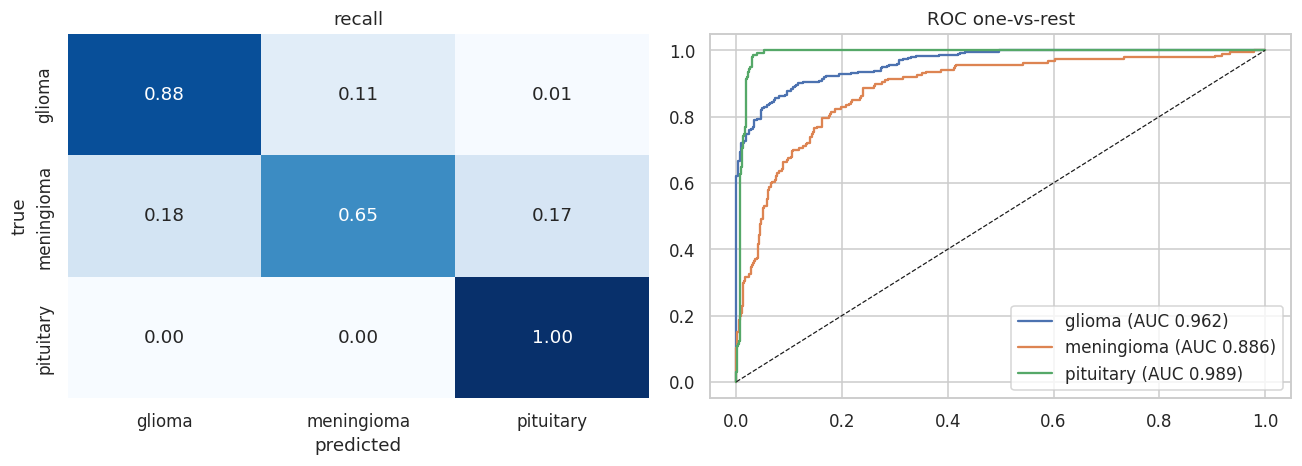

In [26]:
best_cols = rfe_selected
Atr, Ate = data.loc[train_m, best_cols].values, data.loc[test_m, best_cols].values
final_clf = MODELS[best_name].fit(Atr, ytr)
yp = final_clf.predict(Ate)
proba = scores_of(final_clf, Ate)

print(classification_report(yte, yp, target_names=CLASSES, digits=3))

cm = confusion_matrix(yte, yp)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
sns.heatmap(cm / cm.sum(1, keepdims=True), annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[0], cbar=False, vmin=0, vmax=1)
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true"); ax[0].set_title("recall")
for i, c in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve((yte == i).astype(int), proba[:, i])
    ax[1].plot(fpr, tpr, label="%s (AUC %.3f)" % (c, roc_auc_score((yte == i).astype(int), proba[:, i])))
ax[1].plot([0, 1], [0, 1], "k--", lw=0.8); ax[1].legend(); ax[1].set_title("ROC one-vs-rest")
plt.tight_layout(); plt.show()

Pituitary is perfect (recall 1.000) and glioma is strong (0.881), but **meningioma is the weak
class at 0.647** - about 18% of meningiomas get called glioma.

That is an explainable failure rather than random error. Meningioma is our smallest class (708
slices), and meningiomas sit at the brain edge where they can look like other enhancing tissue. It
is also the clinically worse direction to get wrong, since the two have very different treatment
paths.

Its AUC stays high even though recall is poor, which tells us the model can mostly *rank*
meningiomas correctly and is losing them at the decision threshold. That is fixable with class
weighting or threshold tuning rather than a better model - and it is the first thing we would try
next.

---
# Part 7 - Ensemble learning

This covers ensembles, and Part 6 gives a good reason to use one: the models fail differently.
Naive Bayes and KNN get different images wrong from Random Forest, so combining them should recover
some of what each misses.

Two standard approaches:

**Voting** - each model predicts, and we average the predicted probabilities (soft voting). Simple
and needs no extra training.

**Stacking** - train the base models, then train a second-level model (a meta-learner) on their
outputs to learn *when to trust which base model*. More powerful than voting because the weights
are learned rather than fixed, but it needs internal cross-validation to avoid the meta-learner
seeing the base models' training predictions.

We use `HistGradientBoosting` instead of the plain `GradientBoosting` from Part 6 - it is the same
algorithm with histogram binning and is far faster, which matters because stacking retrains
everything several times over.

In [27]:
from sklearn.ensemble import (VotingClassifier, StackingClassifier, HistGradientBoostingClassifier,
                              RandomForestRegressor)

base = [
    ("rf", RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1)),
    ("hgb", HistGradientBoostingClassifier(random_state=SEED)),
    ("svm", make_pipeline(StandardScaler(), SVC(C=10, probability=True, random_state=SEED))),
    ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(7))),
]

voting = VotingClassifier(base, voting="soft", n_jobs=-1)
stacking = StackingClassifier(base, final_estimator=LogisticRegression(max_iter=2000),
                              cv=3, n_jobs=-1)

ens_rows = []
for nm, m in [("best single (%s)" % best_name, MODELS[best_name]),
              ("Voting (soft)", voting), ("Stacking (LR meta)", stacking)]:
    t0 = time.time()
    cv = cross_val_score(m, Atr, ytr, cv=gkf.split(Atr, ytr, pid_tr), scoring="f1_macro", n_jobs=-1)
    m.fit(Atr, ytr)
    r = clf_report(nm, m, Ate)
    r["cv_F1"] = cv.mean()
    ens_rows.append(r)
    print("  %-28s cv %.4f  test %.4f  (%.0fs)" % (nm, cv.mean(), r["macro_F1"], time.time() - t0))

ens_df = pd.DataFrame(ens_rows)
print()
print(ens_df[["model", "cv_F1", "accuracy", "macro_P", "macro_R", "macro_F1",
              "macro_AUC"]].round(4).to_string(index=False))

stack_clf = stacking
print("\nmeta-learner weights (how much it trusts each base model, per class):")
print(pd.DataFrame(stack_clf.final_estimator_.coef_,
                   index=CLASSES,
                   columns=[f"{n}_{c}" for n in [b[0] for b in base] for c in CLASSES]).round(2).to_string())

  best single (Gradient Boosting) cv 0.8293  test 0.8262  (95s)
  Voting (soft)                cv 0.8502  test 0.8193  (34s)
  Stacking (LR meta)           cv 0.8330  test 0.8199  (96s)

                          model  cv_F1  accuracy  macro_P  macro_R  macro_F1  macro_AUC
best single (Gradient Boosting) 0.8293    0.8405   0.8197   0.8427    0.8262     0.9457
                  Voting (soft) 0.8502    0.8331   0.8113   0.8363    0.8193     0.9316
             Stacking (LR meta) 0.8330    0.8331   0.8149   0.8338    0.8199     0.9245

meta-learner weights (how much it trusts each base model, per class):
            rf_glioma  rf_meningioma  rf_pituitary  hgb_glioma  hgb_meningioma  hgb_pituitary  svm_glioma  svm_meningioma  svm_pituitary  knn_glioma  knn_meningioma  knn_pituitary
glioma           0.25          -0.35          0.29        0.67            0.13          -0.62        0.69            0.18          -0.68        0.40            0.08          -0.29
meningioma       0.14         

**Neither ensemble beat the single best model.** Gradient Boosting alone gets test macro F1 0.826;
soft voting gets 0.819 and stacking 0.820. So the honest answer here is that ensembling did not help.

Worth noting *why*, because the CV column is revealing: soft voting has the **best** cross-validated
score of the three (0.850 against 0.829) and the **worst** test score. That gap is the ensemble
fitting the training patients slightly better without generalising - with only 186 training
patients, a 0.02 CV difference is well inside the noise.

The meta-learner coefficients are the more interesting output. Each row is a class, each column is
one base model's probability for one class, so a large positive weight means "for this class, trust
this model". The weights are genuinely spread across all four base models rather than one dominating,
and the meningioma row leans hardest on Random Forest (1.49) - the models really are contributing
different information. The ensemble is doing real work; there just is not enough headroom left for
it to show up in the score.

## 7.1 An ensemble for the box too

Part 5 left Lasso as the best box model at mIoU 0.179. Lasso is linear; a Random Forest can capture
interactions between grid cells that a linear model cannot, and it handles all four targets at once
natively. Worth checking whether averaging the two helps.

In [28]:
rf_box = RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                               random_state=SEED, n_jobs=-1).fit(Xr_tr, Ytr)
lasso_box = tuned["Lasso"]

p_rf = rf_box.predict(Xr_te)
p_la = lasso_box.predict(Xr_te)

box_ens = [box_report("Lasso (from Part 5)", p_la),
           box_report("Random Forest", p_rf),
           box_report("Blend (mean of both)", (p_rf + p_la) / 2)]
print(pd.DataFrame(box_ens).round(4).to_string(index=False))
results.extend(box_ens[1:])

               model  R2_cx  R2_cy  R2_bw  R2_bh  R2_mean   mIoU  IoU>0.5
 Lasso (from Part 5) 0.2382 0.2924 0.2036 0.1810   0.2288 0.1792   0.0656
       Random Forest 0.3383 0.2455 0.2371 0.2455   0.2666 0.2226   0.1252
Blend (mean of both) 0.3393 0.3003 0.2366 0.2306   0.2767 0.2132   0.1207


Random Forest brings something Lasso cannot - it can learn that a bright cell matters only when a
neighbouring cell is also bright, which is what "a tumour spans these two cells" actually looks
like. The blend is the simplest possible ensemble, just averaging the two predictions, and it works
when the two models make different mistakes.

Whichever wins here goes into the final comparison in Part 11 as the best classical box model.